# Far-detector spectra: T2K, NOvA, DUNE and Hyper-K in one line

`far_detector_spectra/<EXP>_FD_spectra.csv` contain, for each experiment and beam mode, the
number of **selected** far-detector events per energy bin *if the oscillation probability were 1*.
To get a prediction you only multiply by the probabilities and add:

$$
\begin{aligned}
N_{\mu\text{-like}} &= P_{\mu\mu}\,[\nu_\mu] + \bar P_{\mu\mu}\,[\bar\nu_\mu] + [\mathrm{NC}_\mu] \\
N_{e\text{-like}}   &= P_{\mu e}\,[\nu_\mu\to e] + \bar P_{\mu e}\,[\bar\nu_\mu\to e]
                     + P_{ee}\,[\nu_e] + \bar P_{ee}\,[\bar\nu_e]
                     + P_{\mu\mu}\,[\text{mis-ID}] + \bar P_{\mu\mu}\,[\overline{\text{mis-ID}}] + [\mathrm{NC}_e]
\end{aligned}
$$

How each file was made (and how well it reproduces the official numbers) is in
`far_detector_spectra/README.md`; the files are rebuilt with `python tools/build_fd_spectra.py`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from nuosc import NeutrinoOscillator
from nuosc.spectra import load_fd_spectra, predict, COMPONENTS

from nuosc.plotting import set_style
SET_STYLE = True     # True: nuosc style (latex_style -> SciencePlots -> default); False: keep your own matplotlib settings
c = set_style(SET_STYLE)   # list of colours used in the plots

EXPERIMENTS = ["T2K", "HyperK", "NOvA", "DUNE"]
E_MAX = {"T2K": 3, "HyperK": 3, "NOvA": 5, "DUNE": 8}      # GeV, for the plots

plot style: latex_style


## 1. What is in a file

In [2]:
s = load_fd_spectra("HyperK")
print(s["header"])
print("\nbins:", len(s["E"]), " baseline:", s["baseline"], "km  density:", s["rho"], "g/cm^3")
print("components per mode:", COMPONENTS)
for name in EXPERIMENTS:
    t = load_fd_spectra(name)
    print(f"{name:7s}: " + ", ".join(f"{m} numu_mu = {t[m]['numu_mu'].sum():8.1f}" for m in ("FHC", "RHC")))

Hyper-Kamiokande far detector: selected events per TRUE-energy bin if P = 1 (see far_detector_spectra/README.md).
Flux: T2K 2020 flux at Super-K (same J-PARC beam, 2.5 deg off-axis, 295 km). Cross section: GENIE sigma/E (smoothed).
Selection: constant efficiency per component, calibrated to Tables XXXVI-XXXVII of the Hyper-K Design Report
(arXiv:1805.04163); e-like columns only below E = 1.25 GeV (E_rec < 1.25 GeV cut); NC shapes approximate.
Exposure: 2.7e22 POT (1.3 MW x 10 yr), nu:nubar = 1:3 -> FHC 6.75e+21 POT, RHC 2.03e+22 POT; 187 kt fiducial (1 tank).
Baseline 295 km, density 2.6 g/cm^3.
Recipe: mu_like = P_mumu*numu_mu + Pbar_mumu*numubar_mu + NC_mu ;
e_like  = P_mue*numu_e + Pbar_mue*numubar_e + P_ee*nue_e + Pbar_ee*nuebar_e
+ P_mumu*numu_misid_e + Pbar_mumu*numubar_misid_e + NC_e
Energies in GeV, events per bin.

bins: 118  baseline: 295.0 km  density: 2.6 g/cm^3
components per mode: ('numu_mu', 'numubar_mu', 'numu_e', 'numubar_e', 'nue_e', 'nuebar_e', 'numu_misid_e', 'numub

## 2. Oscillated spectra (NuFIT 6.0)

Events per GeV for both orderings. Solid: NO, dashed: IO.

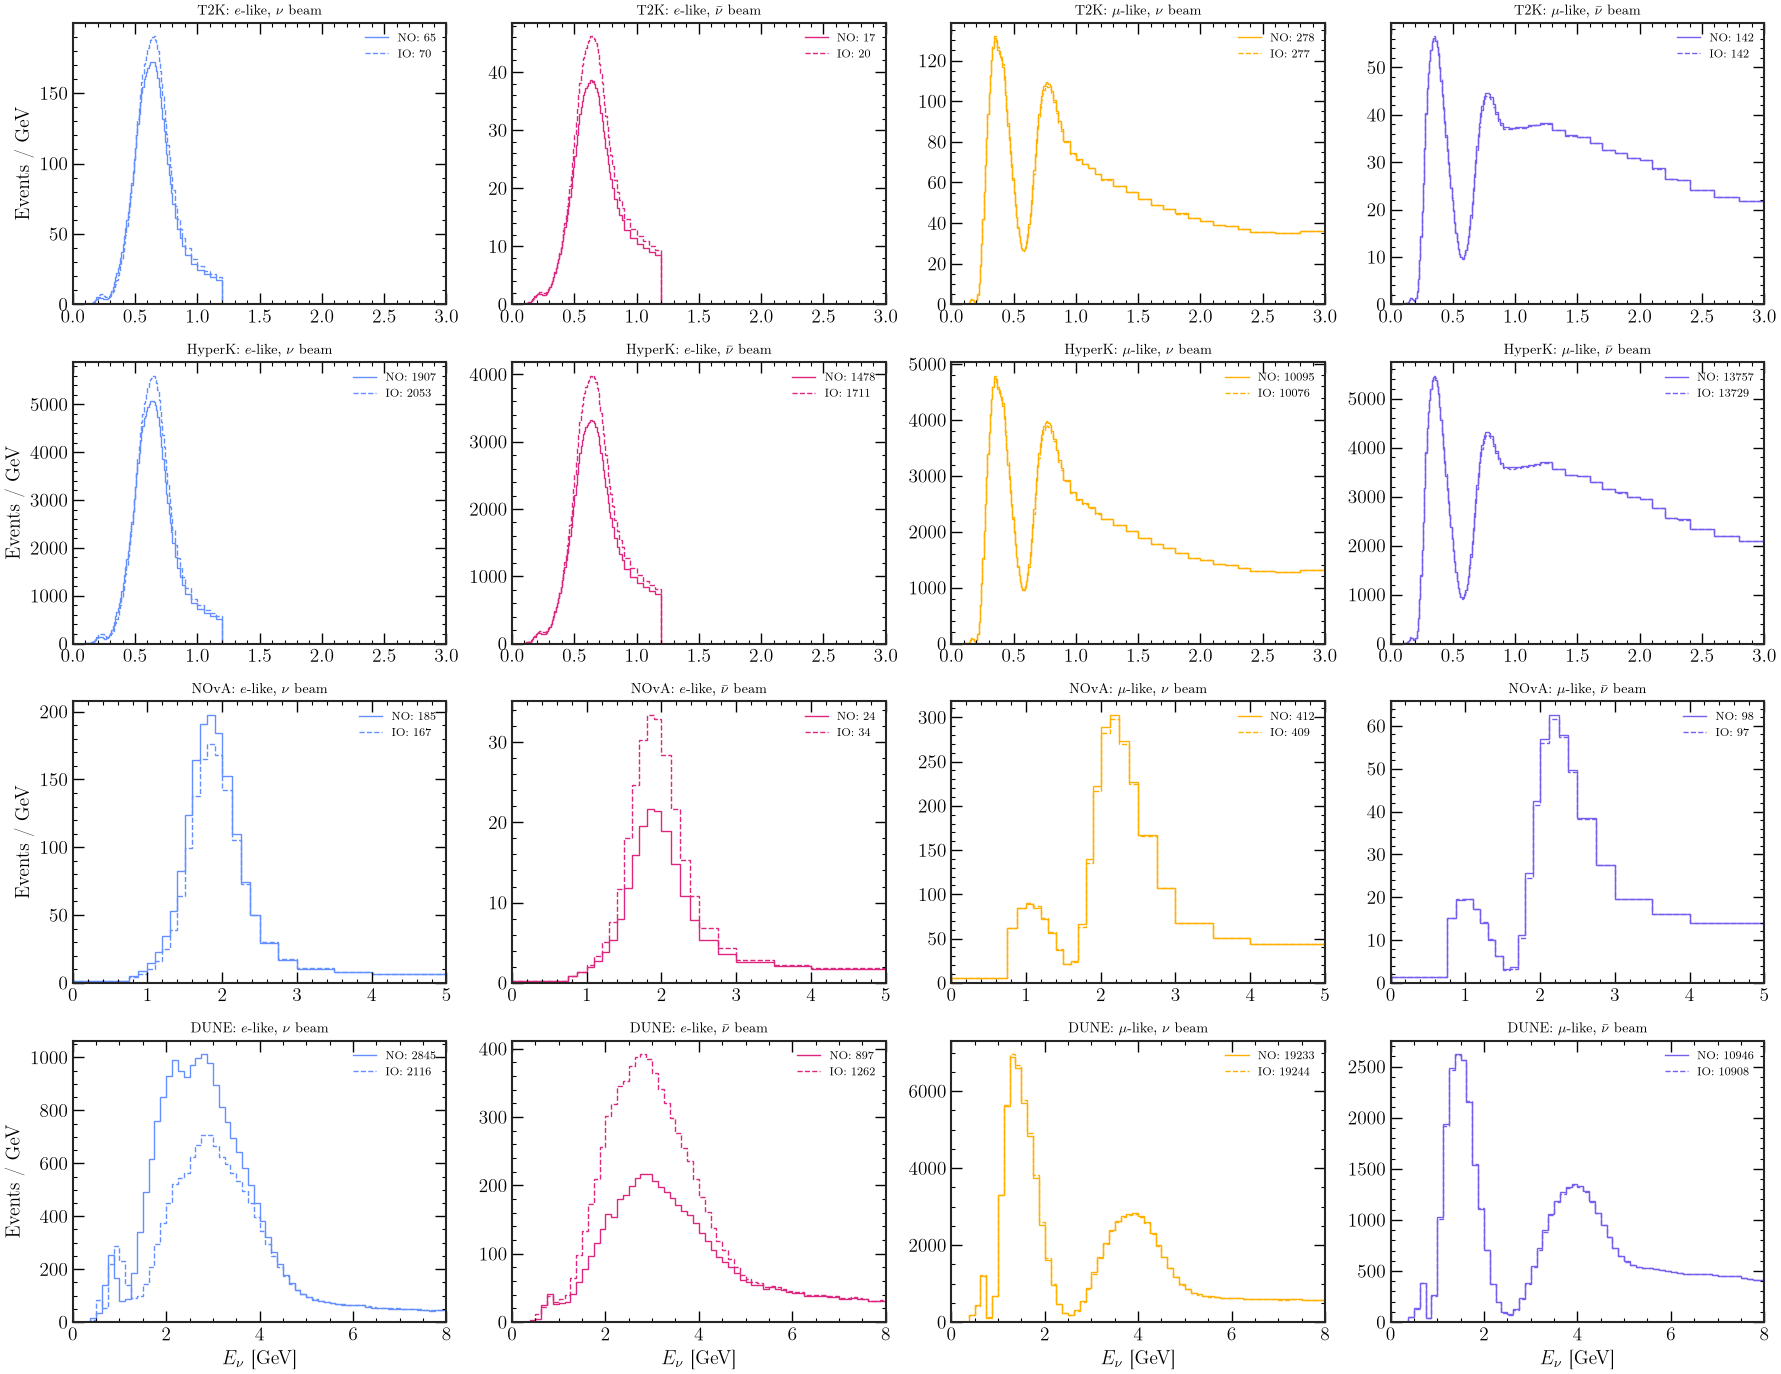

In [3]:
osc = {o: NeutrinoOscillator(o) for o in ("NO", "IO")}
panels = [("FHC", "e_like", r"$e$-like, $\nu$ beam"), ("RHC", "e_like", r"$e$-like, $\bar\nu$ beam"),
          ("FHC", "mu_like", r"$\mu$-like, $\nu$ beam"), ("RHC", "mu_like", r"$\mu$-like, $\bar\nu$ beam")]

fig, axes = plt.subplots(len(EXPERIMENTS), 4, figsize=(18, 14))
for i, name in enumerate(EXPERIMENTS):
    for o, ls in (("NO", "-"), ("IO", "--")):
        p = predict(name, osc[o])
        w = np.diff(p["edges"])
        for j, (m, smp, title) in enumerate(panels):
            ax = axes[i, j]
            ax.stairs(p[m][smp] / w, p["edges"], color=c[j], ls=ls,
                      label=f"{o}: {p[m][smp].sum():.0f}")
            ax.set_xlim(0, E_MAX[name])
            ax.set_title(f"{name}: {title}", fontsize="small")
            ax.legend(fontsize="x-small")
    axes[i, 0].set_ylabel("Events / GeV")
for ax in axes[-1]:
    ax.set_xlabel(r"$E_\nu$ [GeV]")
plt.tight_layout()
plt.show()

## 3. Signal and backgrounds of the $e$-like samples

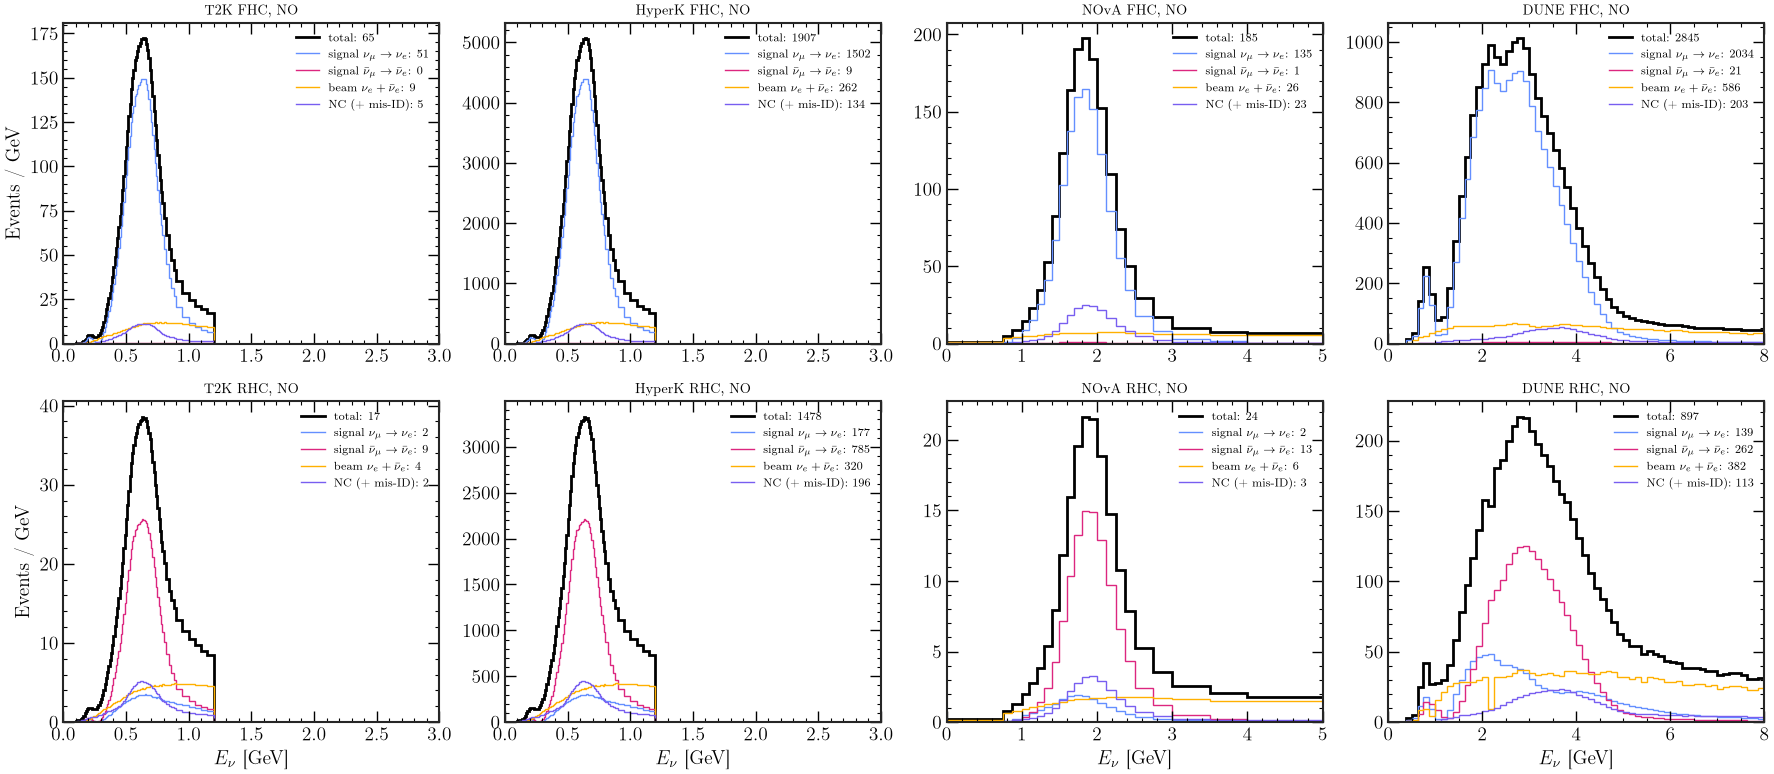

In [4]:
fig, axes = plt.subplots(2, len(EXPERIMENTS), figsize=(18, 8))
groups = [("signal $\\nu_\\mu\\to\\nu_e$", ["numu_e"]), ("signal $\\bar\\nu_\\mu\\to\\bar\\nu_e$", ["numubar_e"]),
          ("beam $\\nu_e+\\bar\\nu_e$", ["nue_e", "nuebar_e"]), ("NC (+ mis-ID)", ["NC_e", "numu_misid_e", "numubar_misid_e"])]
for j, name in enumerate(EXPERIMENTS):
    p = predict(name, osc["NO"])
    w = np.diff(p["edges"])
    for i, m in enumerate(("FHC", "RHC")):
        ax = axes[i, j]
        ax.stairs(p[m]["e_like"] / w, p["edges"], color="k", lw=2, label=f"total: {p[m]['e_like'].sum():.0f}")
        for k, (lab, comps) in enumerate(groups):
            y = sum(p[m][cc] for cc in comps)
            ax.stairs(y / w, p["edges"], color=c[k], label=f"{lab}: {y.sum():.0f}")
        ax.set_xlim(0, E_MAX[name])
        ax.set_title(f"{name} {m}, NO", fontsize="small")
        ax.legend(fontsize="x-small")
    axes[1, j].set_xlabel(r"$E_\nu$ [GeV]")
axes[0, 0].set_ylabel("Events / GeV"); axes[1, 0].set_ylabel("Events / GeV")
plt.tight_layout()
plt.show()

## 4. Bi-event plot for the four experiments

Total $e$-like events in the neutrino vs antineutrino beam when $\delta_{CP}$ varies from $0$ to $2\pi$.
Circles: $\delta_{CP}=0$, squares: $\delta_{CP}=90^\circ$; error bars: $\sqrt N$ at $\delta_{CP}=0$.

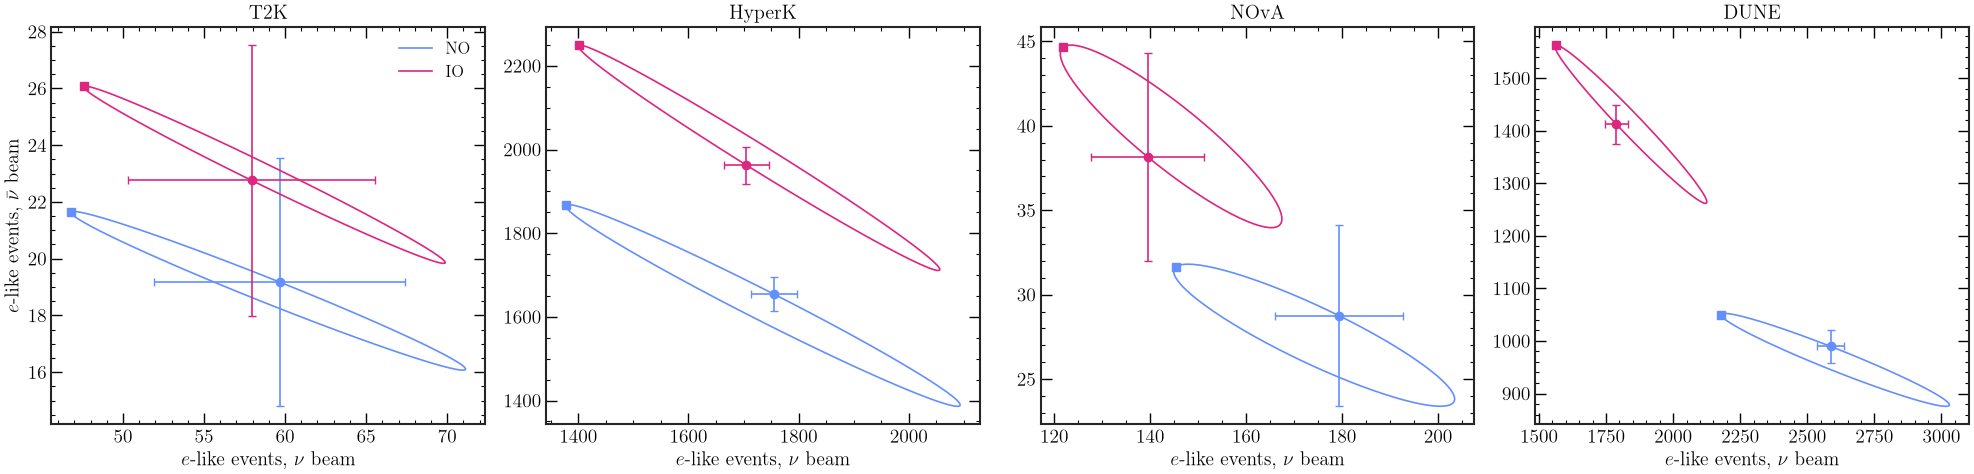

In [5]:
deltas = np.linspace(0, 360, 73)
fig, axes = plt.subplots(1, len(EXPERIMENTS), figsize=(20, 5))
for ax, name in zip(axes, EXPERIMENTS):
    spec = load_fd_spectra(name)
    for i, o in enumerate(("NO", "IO")):
        N = np.array([[predict(name, NeutrinoOscillator(o, delta_cp=d), spectra=spec)[m]["e_like"].sum()
                       for m in ("FHC", "RHC")] for d in deltas])
        ax.plot(N[:, 0], N[:, 1], color=c[i], label=o)
        ax.errorbar(N[0, 0], N[0, 1], xerr=np.sqrt(N[0, 0]), yerr=np.sqrt(N[0, 1]), fmt="o", color=c[i], capsize=3)
        ax.plot(N[18, 0], N[18, 1], "s", color=c[i])
    ax.set_title(name)
    ax.set_xlabel(r"$e$-like events, $\nu$ beam")
axes[0].set_ylabel(r"$e$-like events, $\bar\nu$ beam")
axes[0].legend()
plt.tight_layout()
plt.show()

## 5. Without `nuosc`: the recipe in plain numpy

The files are self-contained: any code that returns $P(E)$ can use them.
Here an example with the two-flavour survival probability for the $\mu$-like sample.

In [6]:
fname = "far_detector_spectra/DUNE_FD_spectra.csv"
cols = [l for l in open(fname) if l.startswith("#")][-1][2:].strip().split(",")   # last comment line = column names
d = dict(zip(cols, np.loadtxt(fname, delimiter=",").T))
E = d["E_center"]
L = 1284.9                                   # km (see the file header)
P_mumu = 1 - 1.0 * np.sin(1.267 * 2.5e-3 * L / E) ** 2      # sin^2(2 theta) = 1, dm2 = 2.5e-3 eV^2
mu_like = P_mumu * d["FHC_numu_mu"] + P_mumu * d["FHC_numubar_mu"] + d["FHC_NC_mu"]
print(f"DUNE FHC mu-like, two-flavour approximation: {mu_like.sum():.0f} events")

DUNE FHC mu-like, two-flavour approximation: 18932 events


## 6. Validation against published numbers

In [7]:
from nuosc.data import t2k_oscillator, load_t2k_oa2019_rates

print("DUNE (NuFIT 6.0 NO): compare with the full GLoBES calculation in dune_tdr_simulation.ipynb")
from nuosc.dune_globes import DUNEGlobes
S = DUNEGlobes().all_samples(osc["NO"])
p = predict("DUNE", osc["NO"])
print(f"   FHC e-like {p['FHC']['e_like'].sum():7.1f} vs {S['nue_app']['total'].sum():7.1f}, "
      f"mu-like {p['FHC']['mu_like'].sum():8.1f} vs {S['numu_dis']['total'].sum():8.1f}")

print("\nT2K Run 1-9, Table XI of arXiv:2101.03779 (in brackets):")
pred, obs = load_t2k_oa2019_rates()
for dcp in sorted(pred):
    p = predict("T2K", t2k_oscillator(dcp))
    print(f"   delta = {dcp:+.2f}: FHC e-like {p['FHC']['e_like'].sum():5.1f} ({pred[dcp]['FHC_e_like']:5.1f}), "
          f"RHC e-like {p['RHC']['e_like'].sum():5.1f} ({pred[dcp]['RHC_e_like']:5.1f}), "
          f"FHC mu-like {p['FHC']['mu_like'].sum():6.1f} ({pred[dcp]['FHC_mu_like']:6.1f})")
print(f"   observed: FHC e-like {obs['FHC_e_like']:.0f}, RHC e-like {obs['RHC_e_like']:.0f}, FHC mu-like {obs['FHC_mu_like']:.0f}")

DUNE (NuFIT 6.0 NO): compare with the full GLoBES calculation in dune_tdr_simulation.ipynb
   FHC e-like  2844.6 vs  2844.6, mu-like  19233.4 vs  19233.4

T2K Run 1-9, Table XI of arXiv:2101.03779 (in brackets):
   delta = -1.57: FHC e-like  74.4 ( 74.4), RHC e-like  17.1 ( 17.1), FHC mu-like  272.4 ( 272.4)
   delta = +0.00: FHC e-like  62.8 ( 62.2), RHC e-like  20.0 ( 19.6), FHC mu-like  272.1 ( 272.0)
   delta = +1.57: FHC e-like  50.6 ( 50.6), RHC e-like  22.5 ( 21.7), FHC mu-like  272.4 ( 272.4)
   delta = +3.14: FHC e-like  62.2 ( 62.7), RHC e-like  19.6 ( 19.3), FHC mu-like  272.8 ( 272.8)
   observed: FHC e-like 75, RHC e-like 15, FHC mu-like 243
